# What are the most demand skills for the top 3 most popular data roles?

In [92]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\HP\Documents\Learning Data Analytics\Python\Luke's Tutorial\Python_Data_Analytics_Course-main\data_jobs.csv")

In [3]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [4]:
def clean_list(skill_list):
    if pd.notna(skill_list):
       return ast.literal_eval(skill_list)

df['job_skills'] = df['job_skills'].apply(clean_list)

In [5]:
df_US = df[df['job_country'] == 'United States']
df_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:00,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,None,NaN
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:00,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:00,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:00,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","[sql, python, java, sql server, gcp, bigquery,...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:00,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","[sql, python, r, mongodb, mongodb, sql server,...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785673,Data Scientist,Asset Management Data Scientist,"New York, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-16 06:01:00,True,False,United States,NaN,NaN,NaN,JPMorgan Chase & Co.,None,NaN
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:00,True,False,United States,NaN,NaN,NaN,"Aara Technologies, Inc","[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:00,False,True,United States,year,157500.0,NaN,Tenet3,"[python, matlab, r]","{'programming': ['python', 'matlab', 'r']}"
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:00,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,None,NaN


In [7]:
df_skills = df_US.explode('job_skills')
df_skills[['job_title_short','job_skills']]

,job_title_short,job_skills
0,Senior Data Engineer,None
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
...,...,...
785692,Data Scientist,r
785703,Data Analyst,None
785705,Data Analyst,sql
785705,Data Analyst,python


In [27]:
df_skill_count = df_skills.groupby(['job_skills','job_title_short']).size()
df_skill_count = df_skill_count.reset_index(name = 'skill_count')
df_skill_count.sort_values('skill_count', ascending = False, inplace = True)

In [28]:
df_skill_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [34]:
job_titles = df_skill_count['job_title_short'].value_counts().head(3).index

In [38]:
job_titles = job_titles.to_list()

In [39]:
job_titles

['Data Scientist', 'Data Engineer', 'Data Analyst']

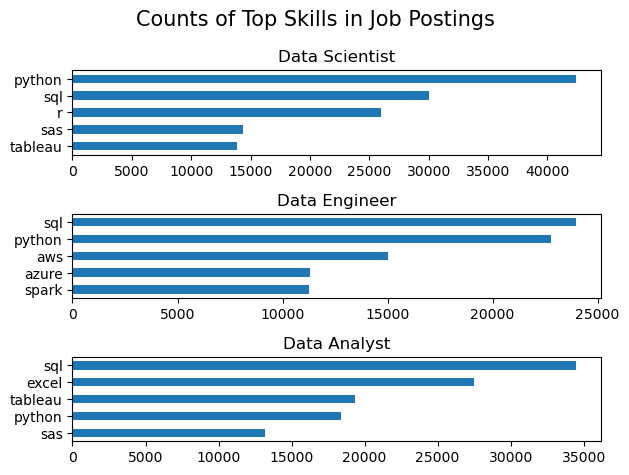

In [72]:
fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):
    df_skill_plot = df_skill_count[df_skill_count['job_title_short'] == job_title].head()
    df_skill_plot.plot(kind = 'barh', x = 'job_skills', title = job_title, ax = ax[i])
    ax[i].invert_yaxis()
    ax[i].legend().set_visible(False)
    ax[i].set_ylabel('')

fig.suptitle('Counts of Top Skills in Job Postings', fontsize = 15)
fig.tight_layout()
plt.show()

In [76]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name = 'jobs_total')

In [80]:
df_skill_perc = df_skill_count.merge(df_job_title_count, on = 'job_title_short', how = 'left')

In [81]:
df_skill_perc

,job_skills,job_title_short,skill_count,jobs_total
0,python,Data Scientist,42379,58830
1,sql,Data Analyst,34452,67816
2,sql,Data Scientist,30034,58830
3,excel,Data Analyst,27519,67816
4,r,Data Scientist,26022,58830
...,...,...,...,...
1865,vue.js,Business Analyst,1,7382
1866,arch,Business Analyst,1,7382
1867,asana,Machine Learning Engineer,1,921
1868,no-sql,Machine Learning Engineer,1,921


In [86]:
df_skill_perc['skill_percent'] = (df_skill_perc['skill_count'] / df_skill_perc['jobs_total']) * 100

In [87]:
df_skill_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


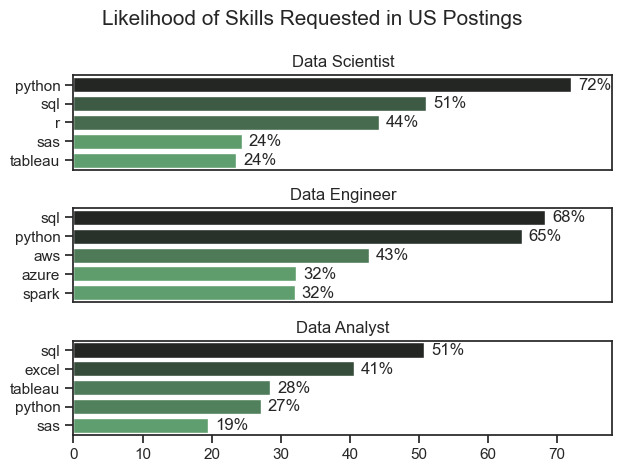

In [119]:
sns.set_theme(style = 'ticks')

fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):
    df_skill_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head()
    # df_skill_plot.plot(kind = 'barh', x = 'job_skills', y = 'skill_percent', title = job_title, ax = ax[i])
    sns.barplot(data = df_skill_plot, x = 'skill_percent', y = 'job_skills', ax = ax[i], legend = False, hue = 'skill_percent', palette = 'dark:g_r')
    ax[i].set_title(job_title)
    # ax[i].legend().set_visible(False)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,78)
    # ax[i].set_xticks([]) # to remove the xaxis since we have data labels

    #for the data labels
    for n,v in enumerate(df_skill_plot['skill_percent']):
        ax[i].text(v + 1,n, f"{v:.0f}%", va = 'center')

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

fig.suptitle('Likelihood of Skills Requested in US Postings', fontsize = 15)
fig.tight_layout()
plt.show()